In [1]:
import pandas as pd
import importlib
import fairnessinsight

importlib.reload(fairnessinsight)
from fairnessinsight.Datasets.BaseDataset import BaseDataset
from fairnessinsight.PostTrainingBias import PostTrainingBias


/Users/i530246/dev/pessoal/SBCAS2025/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/i530246/dev/pessoal/SBCAS2025/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
bd = BaseDataset()
df = pd.read_csv("datasets/heart.csv")
bd.dataset = df
bd.target = "target"
bd.predicted_attr = "target"
bd.random_state = 0
bd.positive_outcome = 0
bd.protected_attr = ["sex"]
bd.protected_attr_mappings = {"sex": {"Female": [0], "Male": [1]}}

bd.max_iter = 2000
bd.n_estimators = 20
bd.random_state = 0
bd.max_depth = 7
bd.criterion = "entropy"
bd.num_repetitions = 2
        

In [3]:
bd.evaluate_pre_training_metrics("sex", 1, bd.dataset, False)

{'Class Imbalance (sex)': 0.36633663366336633,
 'KL Divergence (sex)': 0.20472258782597605,
 'KS (sex)': 0.3007246376811594,
 'Demographic Disparity (sex)': 0.2624505928853755}

In [4]:
acc, f1 = bd.execute_models()

In [5]:
bd.evaluate_post_training_metrics(bd.protected_attr[0], 1)

{'LogisticRegression': {'DPPL (sex)': [-0.3368298368298368,
   -0.5490956072351421],
  'DI (sex)': [1.7727272727272727, 2.388888888888889],
  'DCA (sex)': [0.17647058823529416, 0.05882352941176472],
  'DCR (sex)': [-0.6000000000000001, -2.9230769230769234]},
 'DecisionTreeClassifier': {'DPPL (sex)': [-0.2202797202797202,
   -0.5167958656330749],
  'DI (sex)': [1.477272727272727, 2.388888888888889],
  'DCA (sex)': [0.011111111111111072, 0.0625],
  'DCR (sex)': [-0.09523809523809512, -0.962962962962963]},
 'RandomForestClassifier': {'DPPL (sex)': [-0.11771561771561767,
   -0.44702842377260976],
  'DI (sex)': [1.2086776859504131, 2.0116959064327484],
  'DCA (sex)': [-0.16060606060606064, -0.08552631578947367],
  'DCR (sex)': [0.1512605042016808, -0.8333333333333333]},
 'XGBClassifier': {'DPPL (sex)': [-0.14918414918414918, -0.479328165374677],
  'DI (sex)': [1.30622009569378, 2.0305555555555554],
  'DCA (sex)': [-0.10526315789473684, -0.07352941176470584],
  'DCR (sex)': [0.10000000000000

In [6]:
import numpy as np

percentages = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9 ]  # 0% to 90% removal
results = []
np.random.seed(bd.random_state)
for pct in percentages:
    df_var = df.copy()
    female_idx = df_var[df_var["sex"] == 0].index
    n_remove = int(len(female_idx) * pct)
    if n_remove > 0:
        idx_remove = np.random.choice(female_idx, n_remove, replace=False)
        df_var = df_var.drop(idx_remove)
    bd.dataset = df_var
    acc, f1 = bd.execute_models()
    metrics = bd.evaluate_pre_training_metrics("sex", 1, df_var, False)

    results.append({
        "percentage_removed": pct,
        "metrics": metrics,
        
        "accuracy": acc,
        "f1": f1
    })

# Show results
results


[{'percentage_removed': 0.0,
  'metrics': {'Class Imbalance (sex)': 0.36633663366336633,
   'KL Divergence (sex)': 0.20472258782597605,
   'KS (sex)': 0.3007246376811594,
   'Demographic Disparity (sex)': 0.2624505928853755},
  'accuracy': {'LogisticRegression': 80.328,
   'DecisionTreeClassifier': 76.23,
   'RandomForestClassifier': 80.328,
   'XGBClassifier': 78.689},
  'f1': {'LogisticRegression': 81.368,
   'DecisionTreeClassifier': 76.767,
   'RandomForestClassifier': 82.077,
   'XGBClassifier': 79.924}},
 {'percentage_removed': 0.1,
  'metrics': {'Class Imbalance (sex)': 0.40816326530612246,
   'KL Divergence (sex)': 0.21891361075780147,
   'KS (sex)': 0.3093453273363318,
   'Demographic Disparity (sex)': 0.25953878406708597},
  'accuracy': {'LogisticRegression': 80.388,
   'DecisionTreeClassifier': 75.961,
   'RandomForestClassifier': 80.106,
   'XGBClassifier': 79.578},
  'f1': {'LogisticRegression': 81.72,
   'DecisionTreeClassifier': 76.52,
   'RandomForestClassifier': 81.714

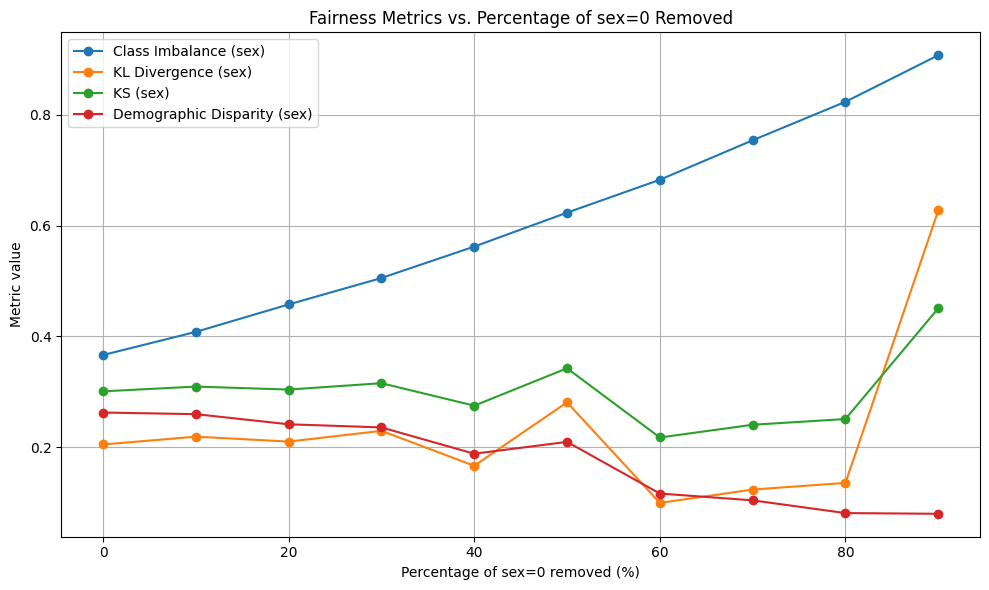

In [7]:
import matplotlib.pyplot as plt

# Extract data for plotting
percentages = [r['percentage_removed']*100 for r in results]
metrics_names = list(results[0]['metrics'].keys())
metrics_data = {name: [r['metrics'][name] for r in results] for name in metrics_names}

plt.figure(figsize=(10, 6))
for name in metrics_names:
    plt.plot(percentages, metrics_data[name], marker='o', label=name)

plt.xlabel('Percentage of sex=0 removed (%)')
plt.ylabel('Metric value')
plt.title('Fairness Metrics vs. Percentage of sex=0 Removed')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

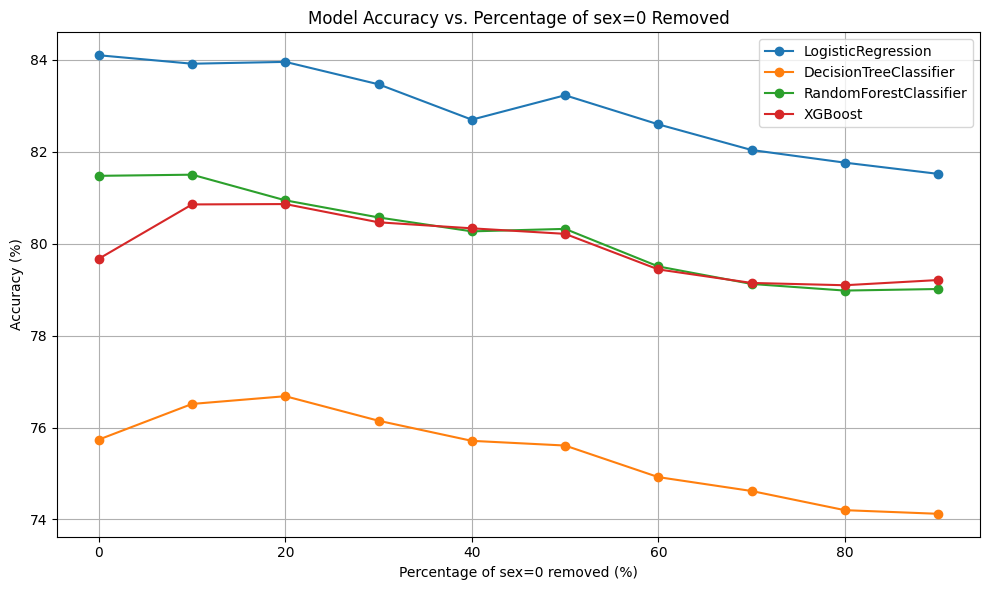

In [17]:
import matplotlib.pyplot as plt

# Extract data for plotting
percentages = [r['percentage_removed']*100 for r in results]
model_names = list(results[0]['accuracy'].keys())
acc_data = {name: [r['accuracy'][name] for r in results] for name in model_names}

plt.figure(figsize=(10, 6))
for name in model_names:
    plt.plot(percentages, acc_data[name], marker='o', label=name)

plt.xlabel('Percentage of sex=0 removed (%)')
plt.ylabel('Accuracy (%)')
plt.title('Model Accuracy vs. Percentage of sex=0 Removed')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

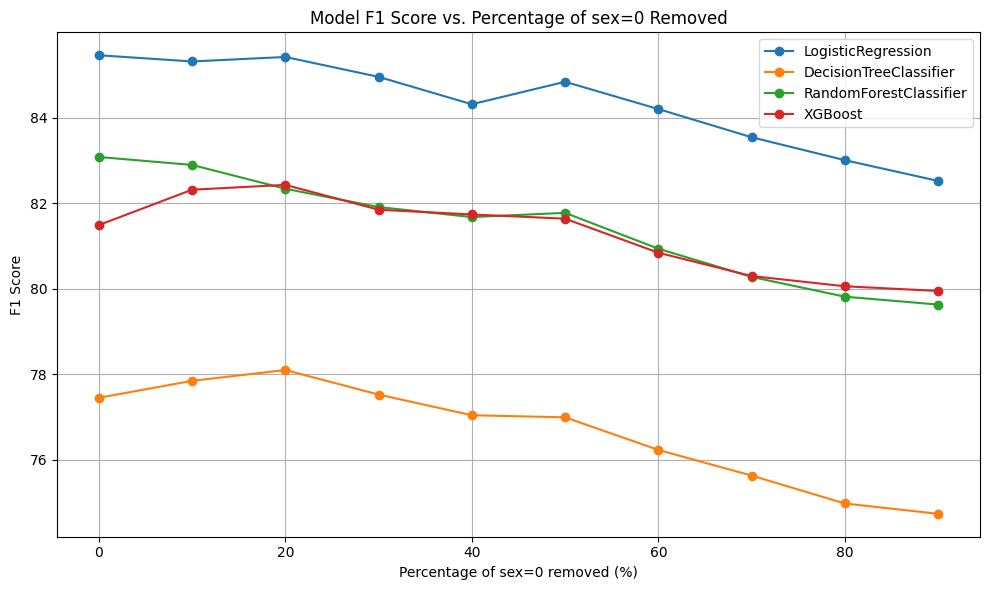

In [18]:
import matplotlib.pyplot as plt

# Extract data for plotting
percentages = [r['percentage_removed']*100 for r in results]
model_names = list(results[0]['f1'].keys())
f1_data = {name: [r['f1'][name] for r in results] for name in model_names}

plt.figure(figsize=(10, 6))
for name in model_names:
    plt.plot(percentages, f1_data[name], marker='o', label=name)

plt.xlabel('Percentage of sex=0 removed (%)')
plt.ylabel('F1 Score')
plt.title('Model F1 Score vs. Percentage of sex=0 Removed')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()